### Load Libraries

In [ ]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

### Load and Inspect Data

In [76]:
# Load Data
df = pd.read_csv("../datasets/processed/engineered_data.csv")
display(df.head())

,Unnamed: 0,id,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,...,Arrival Delay in Minutes,satisfaction,type,Digital_score,Comfort_score,Service_score,Is_business_class,Biz_boarding_interaction,Total_delay,Haul_type
0,0,70172,Male,Loyal Customer,13,Personal Travel,Eco Plus,460,3,4,...,18.0,neutral or dissatisfied,train,3.000000,4.6,3.6,0,0,43.0,short
1,1,5047,Male,disloyal Customer,25,Business travel,Business,235,3,2,...,6.0,neutral or dissatisfied,train,3.000000,1.8,2.4,1,3,7.0,short
2,2,110028,Female,Loyal Customer,26,Business travel,Business,1142,2,2,...,0.0,satisfied,train,3.000000,4.6,3.6,1,5,0.0,medium
3,3,24026,Female,Loyal Customer,25,Business travel,Business,562,2,5,...,9.0,neutral or dissatisfied,train,3.000000,2.6,3.0,1,2,20.0,short
4,4,119299,Male,Loyal Customer,61,Business travel,Business,214,3,3,...,0.0,satisfied,train,3.666667,3.8,3.2,1,5,0.0,short


### Encode Categorical Data

In [77]:
df_train = df.copy()
df_train['label'] = df_train['satisfaction'].apply(lambda x: 1 if x == 'satisfied' else 0)

encode_cols = ['Gender', 'Customer Type', 'Type of Travel', 'Class', 'Haul_type']
df_encoded = pd.get_dummies(df[encode_cols], columns=encode_cols, dtype=int)

df_train = pd.concat([df_train, df_encoded], axis=1).drop('Unnamed: 0', axis=1)

display(df_train.head())

,id,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,Ease of Online booking,...,Customer Type_Loyal Customer,Customer Type_disloyal Customer,Type of Travel_Business travel,Type of Travel_Personal Travel,Class_Business,Class_Eco,Class_Eco Plus,Haul_type_long,Haul_type_medium,Haul_type_short
0,70172,Male,Loyal Customer,13,Personal Travel,Eco Plus,460,3,4,3,...,1,0,0,1,0,0,1,0,0,1
1,5047,Male,disloyal Customer,25,Business travel,Business,235,3,2,3,...,0,1,1,0,1,0,0,0,0,1
2,110028,Female,Loyal Customer,26,Business travel,Business,1142,2,2,2,...,1,0,1,0,1,0,0,0,1,0
3,24026,Female,Loyal Customer,25,Business travel,Business,562,2,5,5,...,1,0,1,0,1,0,0,0,0,1
4,119299,Male,Loyal Customer,61,Business travel,Business,214,3,3,3,...,1,0,1,0,1,0,0,0,0,1


### Model Trainning

##### Model A - Baseline

In [78]:
# Drop unnecessary columns for baseline model (model a)
a_dropped_cols = ['Gender', 'Customer Type', 'Type of Travel', 'Class', 'satisfaction',
                'Digital_score', 'Comfort_score', 'Service_score', 'Is_business_class', 
                'Biz_boarding_interaction', 'Total_delay', 'Haul_type']
a_df_train = df_train.drop(a_dropped_cols, axis=1)
a_df_train.head()

,id,Age,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,Ease of Online booking,Gate location,Food and drink,Online boarding,Seat comfort,...,Customer Type_Loyal Customer,Customer Type_disloyal Customer,Type of Travel_Business travel,Type of Travel_Personal Travel,Class_Business,Class_Eco,Class_Eco Plus,Haul_type_long,Haul_type_medium,Haul_type_short
0,70172,13,460,3,4,3,1,5,3,5,...,1,0,0,1,0,0,1,0,0,1
1,5047,25,235,3,2,3,3,1,3,1,...,0,1,1,0,1,0,0,0,0,1
2,110028,26,1142,2,2,2,2,5,5,5,...,1,0,1,0,1,0,0,0,1,0
3,24026,25,562,2,5,5,5,2,2,2,...,1,0,1,0,1,0,0,0,0,1
4,119299,61,214,3,3,3,3,4,5,5,...,1,0,1,0,1,0,0,0,0,1


In [79]:
# Create train dataset
a_X_train = a_y_train = a_df_train[a_df_train['type'] == 'train']
a_X_train = a_X_train.drop(['type', 'label'], axis=1)
a_y_train = a_y_train['label']

# Create test dataset
a_X_test = a_y_test = a_df_train[a_df_train['type'] == 'test']
a_X_test = a_X_test.drop(['type', 'label'], axis=1)
a_y_test = a_y_test['label']

In [80]:
# Create model_a
model_a = RandomForestClassifier(n_estimators=100, random_state=42)
model_a.fit(a_X_train, a_y_train)

# Make predictions
a_y_pred = model_a.predict(a_X_test)

# Evaluate model_a
accuracy = accuracy_score(a_y_test, a_y_pred)
print(f"Accuracy: {accuracy:.3f}")
print(classification_report(a_y_test, a_y_pred))


Accuracy: 0.965
              precision    recall  f1-score   support

           0       0.96      0.98      0.97     14528
           1       0.97      0.94      0.96     11365

    accuracy                           0.96     25893
   macro avg       0.97      0.96      0.96     25893
weighted avg       0.96      0.96      0.96     25893



##### Model B - Feature Engineered Model

In [81]:
# Drop unnecessary columns for baseline model (model b)
b_dropped_cols = ['Gender', 'Customer Type', 'Type of Travel', 'Class', 'satisfaction',
                'Inflight wifi service', 'Departure/Arrival time convenient', 'Ease of Online booking', 
                'Online boarding','Food and drink', 'Seat comfort', 'Inflight entertainment', 'Leg room service', 
                'Cleanliness','Gate location', 'On-board service', 'Baggage handling', 'Checkin service', 
                'Inflight service', 'Haul_type']
b_df_train = df_train.drop(b_dropped_cols, axis=1)
display(b_df_train.head())

,id,Age,Flight Distance,Departure Delay in Minutes,Arrival Delay in Minutes,type,Digital_score,Comfort_score,Service_score,Is_business_class,...,Customer Type_Loyal Customer,Customer Type_disloyal Customer,Type of Travel_Business travel,Type of Travel_Personal Travel,Class_Business,Class_Eco,Class_Eco Plus,Haul_type_long,Haul_type_medium,Haul_type_short
0,70172,13,460,25,18.0,train,3.000000,4.6,3.6,0,...,1,0,0,1,0,0,1,0,0,1
1,5047,25,235,1,6.0,train,3.000000,1.8,2.4,1,...,0,1,1,0,1,0,0,0,0,1
2,110028,26,1142,0,0.0,train,3.000000,4.6,3.6,1,...,1,0,1,0,1,0,0,0,1,0
3,24026,25,562,11,9.0,train,3.000000,2.6,3.0,1,...,1,0,1,0,1,0,0,0,0,1
4,119299,61,214,0,0.0,train,3.666667,3.8,3.2,1,...,1,0,1,0,1,0,0,0,0,1


In [82]:
# Create train dataset
b_X_train = b_y_train = b_df_train[b_df_train['type'] == 'train']
b_X_train = b_X_train.drop(['type', 'label'], axis=1)
b_y_train = b_y_train['label']

# Create test dataset
b_X_test = b_y_test = b_df_train[b_df_train['type'] == 'test']
b_X_test = b_X_test.drop(['type', 'label'], axis=1)
b_y_test = b_y_test['label']

In [83]:
# Create model_b
model_b = RandomForestClassifier(n_estimators=100, random_state=42)
model_b.fit(b_X_train, b_y_train)

# Make predictions
b_y_pred = model_b.predict(b_X_test)

# Evaluate model_b
accuracy = accuracy_score(b_y_test, b_y_pred)
print(f"Accuracy: {accuracy:.3f}")
print(classification_report(b_y_test, b_y_pred))


Accuracy: 0.937
              precision    recall  f1-score   support

           0       0.93      0.96      0.94     14528
           1       0.94      0.91      0.93     11365

    accuracy                           0.94     25893
   macro avg       0.94      0.93      0.94     25893
weighted avg       0.94      0.94      0.94     25893



### Visualize Models

In [88]:
importance_A = pd.DataFrame({
    'Feature': a_X_train.columns,
    'Importance': model_a.feature_importances_,
    'Model': 'Model A'
}).sort_values(by=['Importance'], ascending=False).head(10)

importance_B = pd.DataFrame({
    'Feature': b_X_train.columns,
    'Importance': model_b.feature_importances_,
    'Model': 'Model B'
}).sort_values(by=['Importance'], ascending=False).head(10)

In [97]:
importance_B.head()

,Feature,Importance,Model
5,Digital_score,0.168154,Model B
9,Biz_boarding_interaction,0.159376,Model B
6,Comfort_score,0.110325,Model B
7,Service_score,0.070847,Model B
0,id,0.056296,Model B


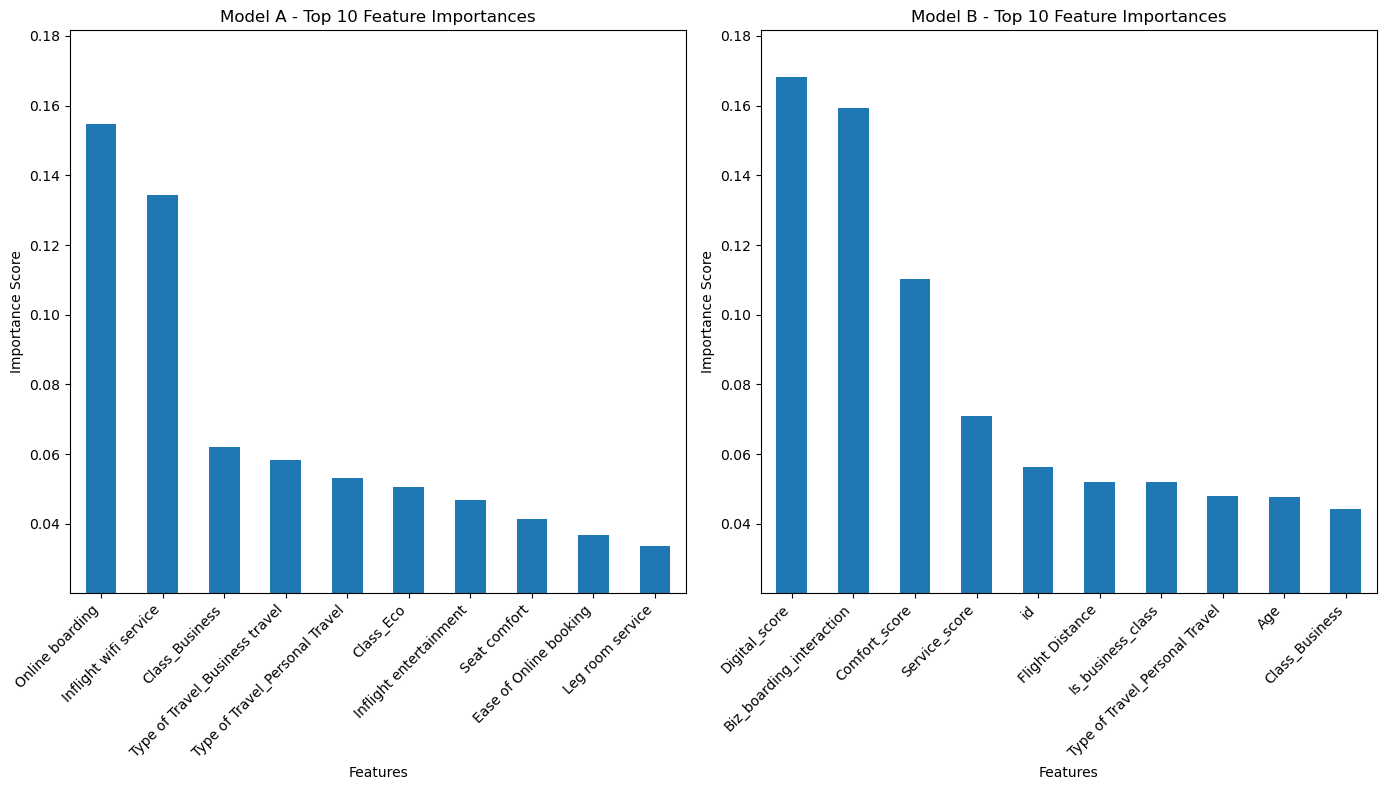

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(14, 8))

importance_A.plot.bar(x='Feature', y='Importance', ax=ax[0])
ax[0].set_title('Model A - Top 10 Feature Importances')
ax[0].set_xlabel('Features')
ax[0].set_ylabel('Importance Score')
ax[0].set_xticklabels(ax[0].get_xticklabels(), rotation=45, ha='right')

importance_B.plot.bar(x='Feature', y='Importance', ax=ax[1])
ax[1].set_title('Model B - Top 10 Feature Importances')
ax[1].set_xlabel('Features')
ax[1].set_ylabel('Importance Score')
ax[1].set_xticklabels(ax[1].get_xticklabels(), rotation=45, ha='right')


max_importance = max(importance_A['Importance'].max(), importance_B['Importance'].max())
min_importance = min(importance_A['Importance'].min(), importance_B['Importance'].min())

y_padding = (max_importance - min_importance) * 0.1
ax[0].set_ylim([min_importance - y_padding, max_importance + y_padding])
ax[1].set_ylim([min_importance - y_padding, max_importance + y_padding])

legend_a = ax[0].legend()
legend_a.remove()

legend_b = ax[1].legend()
legend_b.remove()

plt.tight_layout()
plt.show()